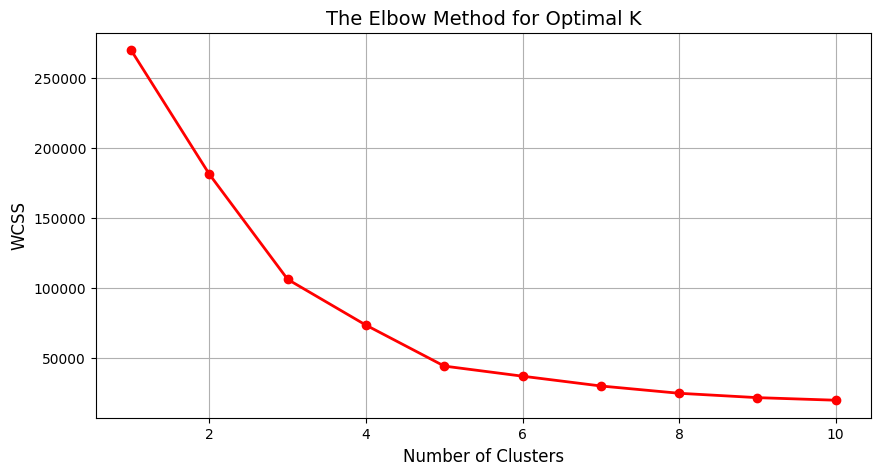

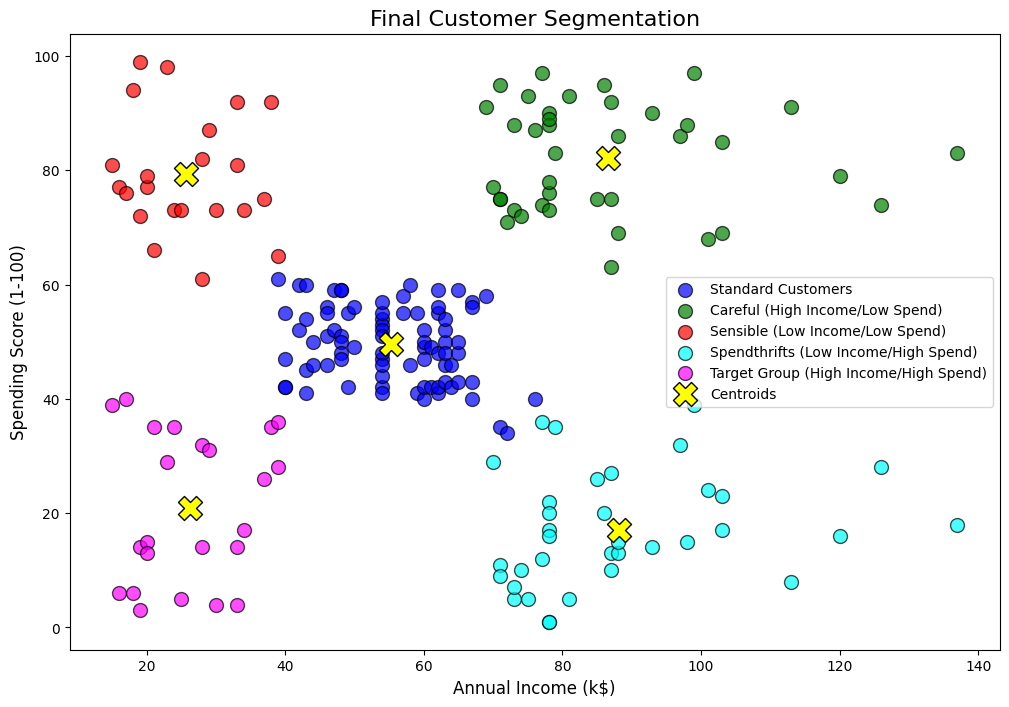

In [8]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings

# Suppress warnings to keep the output clean
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# 2. Select Features (Annual Income and Spending Score)
# We use .values to convert to numpy array and avoid feature name warnings
X = df.iloc[:, [3, 4]].values

# 3. The Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    # Using n_init=10 explicitly to avoid future version warnings
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method result
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='red', linewidth=2)
plt.title('The Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.grid(True)
plt.show()

# 4. Applying K-Means to the dataset with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# 5. Visualizing the Clusters with professional styling
plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'cyan', 'magenta']
labels = [
    'Standard Customers', 
    'Careful (High Income/Low Spend)', 
    'Sensible (Low Income/Low Spend)', 
    'Spendthrifts (Low Income/High Spend)', 
    'Target Group (High Income/High Spend)'
]

for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=100, c=colors[i], label=labels[i], edgecolors='black', alpha=0.7)

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', marker='X', edgecolors='black')

plt.title('Final Customer Segmentation', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(loc='best')
plt.show()